<div style="text-align:center; padding:20px;">

<h1>📊 Retail Sales Exploratory Data Analysis</h1>

<h3>Oasis Infobyte Internship – Data Analytics Task 1</h3>

<p>
An exploratory data analysis project focused on identifying sales trends,
customer behavior, product category performance, and actionable business insights.
</p>

<br>

<b>Tools Used:</b> Python | Pandas | NumPy | Matplotlib | Seaborn

</div>

<hr>

<h2>🎯 Project Objective</h2>

<p>
The objective of this project is to perform an Exploratory Data Analysis (EDA)
on retail sales data to identify meaningful patterns in sales performance,
customer demographics, product categories, and seasonal trends.
</p>

<h3>Key Questions</h3>

<ul>
    <li>How do sales change over time?</li>
    <li>Which months and quarters generate the highest revenue?</li>
    <li>Which customer demographics contribute the most to sales?</li>
    <li>Which product categories perform best?</li>
    <li>What factors are most strongly associated with total sales?</li>
</ul>

<hr>

<h2>1. Data Preparation</h2>

<h3>1.1 Import Libraries</h3>

In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
# Set visualization theme
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titleweight'] = 'bold'

<h3>1.2 Load Dataset</h3>

In [55]:
df = pd.read_csv('Retail_Sales-selected-columns (1).csv')

df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0


<h2>📁 Dataset Overview</h2>

<p>
The dataset contains retail transaction data collected between
<b>2022 and 2023</b>. It includes customer demographics, transaction details,
product categories, pricing information, and cost data.
</p>

<h3>Key Features</h3>

<ul>
    <li><b>transactions_id</b> – Unique transaction identifier</li>
    <li><b>sale_date</b> – Date of transaction</li>
    <li><b>customer_id</b> – Unique customer identifier</li>
    <li><b>gender</b> – Customer gender</li>
    <li><b>age</b> – Customer age</li>
    <li><b>category</b> – Product category</li>
    <li><b>quantiy</b> – Quantity purchased</li>
    <li><b>price_per_unit</b> – Price per unit</li>
    <li><b>cogs</b> – Cost of goods sold</li>
</ul>

<hr>

<h3>1.3 Initial Data Inspection</h3>

In [56]:
# Display basic information about the dataset
df.info()
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("Column Names:")
print(df.columns.tolist())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   transactions_id  2000 non-null   int64  
 1   sale_date        2000 non-null   object 
 2   sale_time        2000 non-null   object 
 3   customer_id      2000 non-null   int64  
 4   gender           2000 non-null   object 
 5   age              1990 non-null   float64
 6   category         2000 non-null   object 
 7   quantiy          1997 non-null   float64
 8   price_per_unit   1997 non-null   float64
 9   cogs             1997 non-null   float64
dtypes: float64(4), int64(2), object(4)
memory usage: 156.4+ KB
Number of Rows: 2000
Number of Columns: 10
Column Names:
['transactions_id', 'sale_date', 'sale_time', 'customer_id', 'gender', 'age', 'category', 'quantiy', 'price_per_unit', 'cogs']


<h3>1.4 Missing Value Analysis</h3>

In [57]:
# Check missing values in each column
df.isnull().sum()

,0
transactions_id,0
sale_date,0
sale_time,0
customer_id,0
gender,0
age,10
category,0
quantiy,3
price_per_unit,3
cogs,3


In [58]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

transactions_id    0.00
sale_date          0.00
sale_time          0.00
customer_id        0.00
gender             0.00
age                0.50
category           0.00
quantiy            0.15
price_per_unit     0.15
cogs               0.15
dtype: float64


<h3>1.5 Data Cleaning</h3>

In [59]:
# Remove rows with missing values
df = df.dropna()

# Check the new dataset shape
print("New dataset shape:", df.shape)

New dataset shape: (1987, 10)


<h3>1.6 Data Type Conversion and Feature Engineering</h3>

In [60]:
# Convert sale_date to datetime format
df['sale_date'] = pd.to_datetime(df['sale_date'])

# Convert sale_time to time format
df['sale_time'] = pd.to_datetime(
    df['sale_time'],
    format='%H:%M:%S'
).dt.time

In [61]:
# Create Total Sales column
df['total_sales'] = df['quantiy'] * df['price_per_unit']

# Extract Year, Month, and Quarter
df['year'] = df['sale_date'].dt.year
df['month'] = df['sale_date'].dt.month
df['month_name'] = df['sale_date'].dt.month_name()
df['quarter'] = df['sale_date'].dt.quarter

# Display the first 5 rows
df.head()

,transactions_id,sale_date,sale_time,customer_id,gender,age,category,quantiy,price_per_unit,cogs,total_sales,year,month,month_name,quarter
0,180,2022-11-05,10:47:00,117,Male,41.0,Clothing,3.0,300.0,129.0,900.0,2022,11,November,4
1,522,2022-07-09,11:00:00,52,Male,46.0,Beauty,3.0,500.0,145.0,1500.0,2022,7,July,3
2,559,2022-12-12,10:48:00,5,Female,40.0,Clothing,4.0,300.0,84.0,1200.0,2022,12,December,4
3,1180,2022-01-06,08:53:00,85,Male,41.0,Clothing,3.0,300.0,129.0,900.0,2022,1,January,1
4,1522,2022-11-14,08:35:00,48,Male,46.0,Beauty,3.0,500.0,235.0,1500.0,2022,11,November,4


**2.Descriptive Analysis - Sales Performance Overview**




In [62]:
# Descriptive statistics for numerical columns
df.describe()

,transactions_id,sale_date,customer_id,age,quantiy,price_per_unit,cogs,total_sales,year,month,quarter
count,1987.000000,1987,1987.000000,1987.000000,1987.00000,1987.000000,1987.000000,1987.000000,1987.000000,1987.000000,1987.000000
mean,1000.513337,2023-02-18 10:29:46.411675904,66.284852,41.351283,2.51384,179.924509,95.081933,457.086059,2022.513840,7.967287,2.967287
min,1.000000,2022-01-01 00:00:00,1.000000,18.000000,1.00000,25.000000,6.250000,25.000000,2022.000000,1.000000,1.000000
25%,499.500000,2022-09-24 12:00:00,24.000000,29.000000,1.00000,30.000000,13.000000,60.000000,2022.000000,5.000000,2.000000
50%,1001.000000,2023-01-18 00:00:00,69.000000,42.000000,3.00000,50.000000,27.500000,150.000000,2023.000000,9.000000,3.000000
75%,1502.500000,2023-09-14 00:00:00,102.000000,53.000000,4.00000,300.000000,147.000000,900.000000,2023.000000,11.000000,4.000000
max,2000.000000,2023-12-31 00:00:00,155.000000,64.000000,4.00000,500.000000,620.000000,2000.000000,2023.000000,12.000000,4.000000
std,578.274413,NaN,44.964430,13.662653,1.13277,189.441178,122.032280,560.862242,0.499934,3.421459,1.097207


In [63]:
# Calculate descriptive statistics

numerical_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns

statistics = pd.DataFrame({
    'Mean': df[numerical_columns].mean(),
    'Median': df[numerical_columns].median(),
    'Mode': df[numerical_columns].mode().iloc[0],
    'Standard Deviation': df[numerical_columns].std()
})

statistics

,Mean,Median,Mode,Standard Deviation
transactions_id,1000.513337,1001.0,1.0,578.274413
customer_id,66.284852,69.0,1.0,44.964430
age,41.351283,42.0,43.0,13.662653
quantiy,2.513840,3.0,4.0,1.132770
price_per_unit,179.924509,50.0,50.0,189.441178
cogs,95.081933,27.5,13.5,122.032280
total_sales,457.086059,150.0,50.0,560.862242


In [64]:
# Summary of categorical columns
df.describe(include='object')

,sale_time,gender,category,month_name
count,1987,1987,1987,1987
unique,763,2,3,12
top,21:35:00,Female,Clothing,December
freq,9,1012,698,297


**3. Sales Trend Analysis**

In [65]:
# Calculate key sales metrics

total_sales = df['total_sales'].sum()

total_transactions = df['transactions_id'].nunique()

average_transaction_value = df['total_sales'].mean()

total_quantity_sold = df['quantiy'].sum()

print("Total Sales:", round(total_sales, 2))
print("Total Transactions:", total_transactions)
print("Average Transaction Value:", round(average_transaction_value, 2))
print("Total Quantity Sold:", total_quantity_sold)

Total Sales: 908230.0
Total Transactions: 1987
Average Transaction Value: 457.09
Total Quantity Sold: 4995.0


In [66]:
# Calculate monthly sales
monthly_sales = df.groupby(
    ['year', 'month', 'month_name']
)['total_sales'].sum().reset_index()

# Sort by year and month
monthly_sales = monthly_sales.sort_values(['year', 'month'])

monthly_sales

,year,month,month_name,total_sales
0,2022,1,January,22635.0
1,2022,2,February,16110.0
2,2022,3,March,23455.0
3,2022,4,April,28535.0
4,2022,5,May,24480.0
5,2022,6,June,20700.0
6,2022,7,July,22195.0
7,2022,8,August,21075.0
8,2022,9,September,61620.0
9,2022,10,October,67735.0


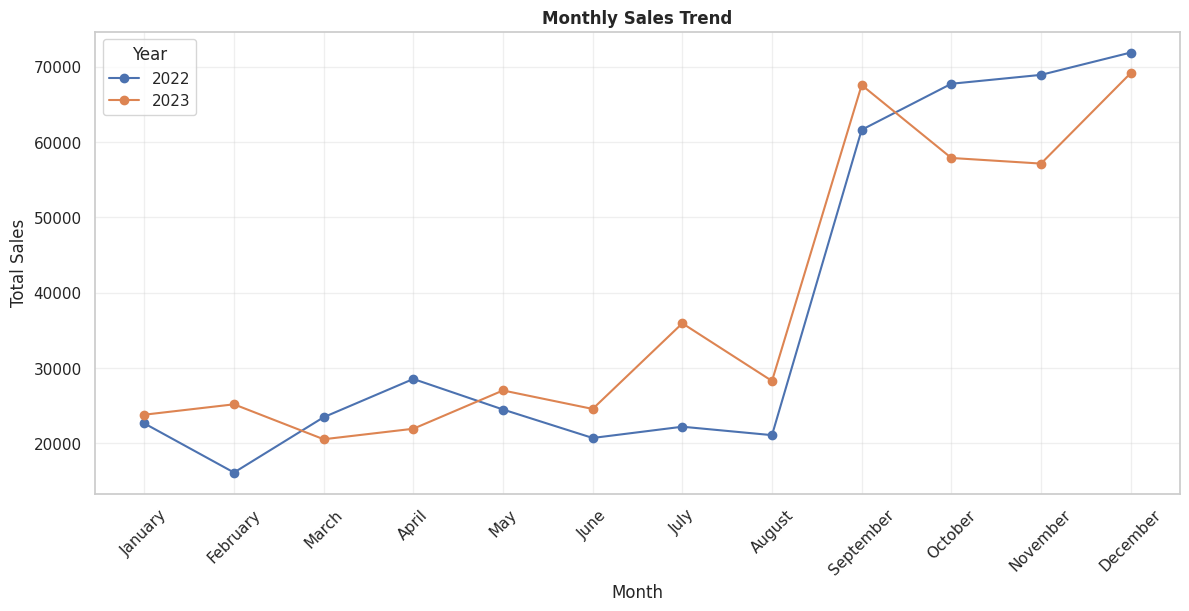

In [67]:
plt.figure(figsize=(14, 6))

for year in monthly_sales['year'].unique():
    data = monthly_sales[monthly_sales['year'] == year]

    plt.plot(
        data['month_name'],
        data['total_sales'],
        marker='o',
        label=str(year)
    )

plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.legend(title='Year')
plt.grid(True, alpha=0.3)

plt.show()

<h4>📌 Observation</h4>

<ul>
    <li>Sales remained relatively lower during the first half of the year.</li>
    <li>A significant increase in sales can be observed from September onwards.</li>
    <li>December was one of the strongest-performing months.</li>
    <li>The results indicate a possible seasonal sales pattern during the final quarter.</li>
</ul>

In [68]:
# Calculate quarterly sales
quarterly_sales = df.groupby(
    ['year', 'quarter']
)['total_sales'].sum().reset_index()

quarterly_sales

,year,quarter,total_sales
0,2022,1,62200.0
1,2022,2,73715.0
2,2022,3,104890.0
3,2022,4,208530.0
4,2023,1,69490.0
5,2023,2,73490.0
6,2023,3,131755.0
7,2023,4,184160.0


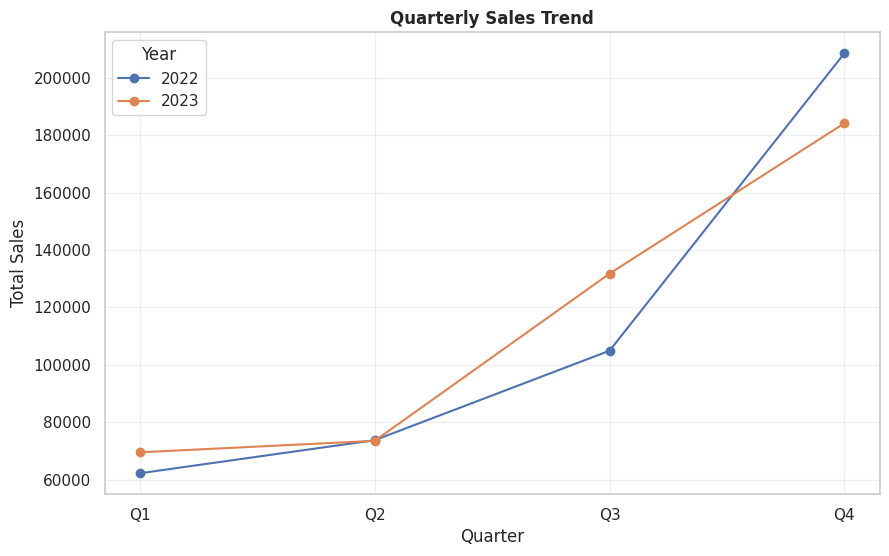

In [69]:
plt.figure(figsize=(10, 6))

for year in quarterly_sales['year'].unique():
    data = quarterly_sales[quarterly_sales['year'] == year]

    plt.plot(
        data['quarter'],
        data['total_sales'],
        marker='o',
        label=str(year)
    )

plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.xticks([1, 2, 3, 4], ['Q1', 'Q2', 'Q3', 'Q4'])
plt.legend(title='Year')
plt.grid(True, alpha=0.3)

plt.show()

**4. Customer Demographic Analysis**

<h4>📌 Observation</h4>

<ul>
    <li>Q4 generated the highest sales in both years.</li>
    <li>Q4 2022 recorded the highest quarterly sales at <b>208,530</b>.</li>
    <li>Sales generally increased during the second half of the year.</li>
    <li>The business should prepare inventory and marketing strategies before Q4.</li>
</ul>

In [70]:
# Calculate sales by gender
gender_sales = df.groupby('gender')['total_sales'].sum().reset_index()

# Calculate number of transactions by gender
gender_transactions = df['gender'].value_counts().reset_index()
gender_transactions.columns = ['gender', 'transactions']

print("Sales by Gender:")
print(gender_sales)

print("\nTransactions by Gender:")
print(gender_transactions)

Sales by Gender:
   gender  total_sales
0  Female     463110.0
1    Male     445120.0

Transactions by Gender:
   gender  transactions
0  Female          1012
1    Male           975


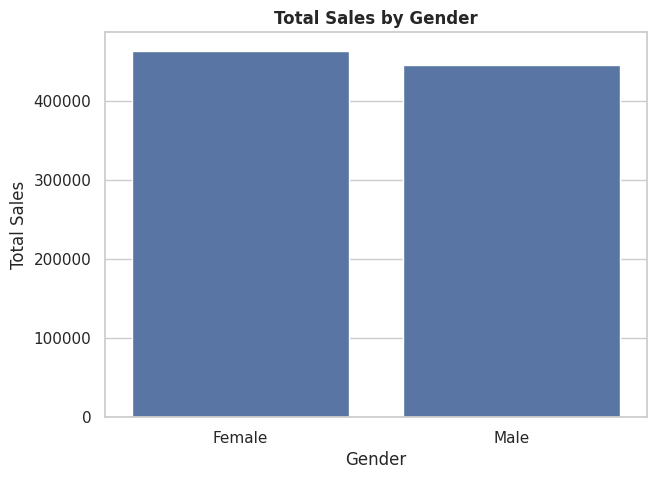

In [71]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=gender_sales,
    x='gender',
    y='total_sales'
)

plt.title('Total Sales by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Sales')

plt.show()

<h4>📌 Observation</h4>

<ul>
    <li>Female customers generated slightly higher total sales than male customers.</li>
    <li>Female customers also recorded more transactions.</li>
    <li>However, the difference between the two groups is relatively small.</li>
</ul>

In [72]:
# Create age groups
bins = [17, 25, 35, 45, 55, 65]
labels = ['18-25', '26-35', '36-45', '46-55', '56-65']

df['age_group'] = pd.cut(
    df['age'],
    bins=bins,
    labels=labels
)

# Calculate sales by age group
age_group_sales = df.groupby(
    'age_group',
    observed=False
)['total_sales'].sum().reset_index()

age_group_sales

,age_group,total_sales
0,18-25,168960.0
1,26-35,196870.0
2,36-45,183665.0
3,46-55,200305.0
4,56-65,158430.0


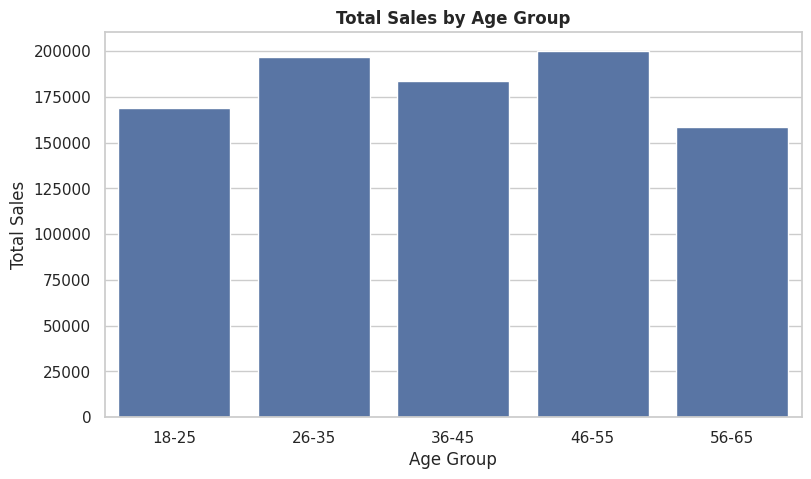

In [73]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=age_group_sales,
    x='age_group',
    y='total_sales'
)

plt.title('Total Sales by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Total Sales')

plt.show()

**5. Product Category Analysis**

<h4>📌 Observation</h4>

<ul>
    <li>The 46–55 age group generated the highest total sales.</li>
    <li>The 26–35 age group was the second-highest contributor.</li>
    <li>The 56–65 age group generated the lowest sales among the analysed age groups.</li>
</ul>

In [74]:
# Calculate sales and quantity sold by category
category_analysis = df.groupby('category').agg(
    total_sales=('total_sales', 'sum'),
    total_quantity=('quantiy', 'sum'),
    transactions=('transactions_id', 'count')
).reset_index()

# Sort by total sales
category_analysis = category_analysis.sort_values(
    by='total_sales',
    ascending=False
)

category_analysis

,category,total_sales,total_quantity,transactions
2,Electronics,311445.0,1682.0,678
1,Clothing,309995.0,1780.0,698
0,Beauty,286790.0,1533.0,611


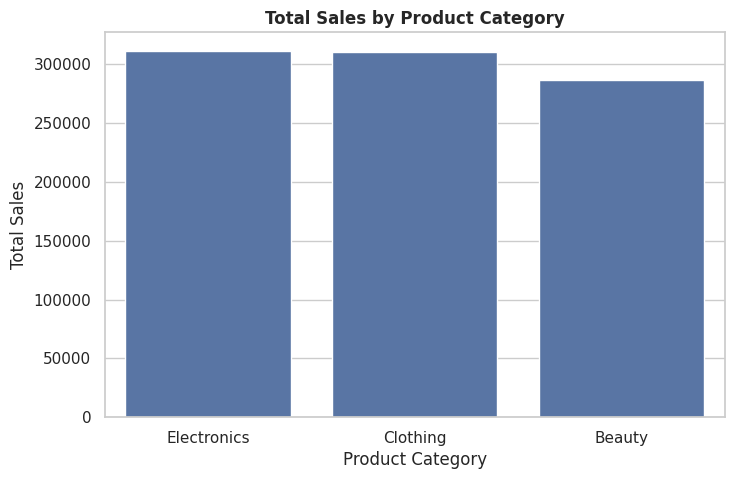

In [75]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=category_analysis,
    x='category',
    y='total_sales'
)

plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')

plt.show()

**6. Correlation Analysis**

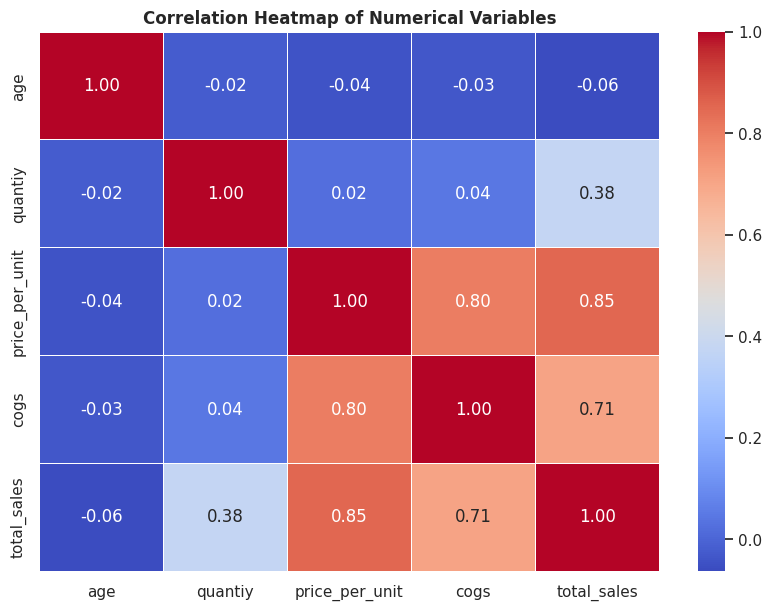

In [76]:
# Select numerical columns for correlation analysis
numeric_columns = [
    'age',
    'quantiy',
    'price_per_unit',
    'cogs',
    'total_sales'
]

# Calculate correlation matrix
correlation_matrix = df[numeric_columns].corr()

# Create the heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

In [77]:
# Calculate sales by category and gender
category_gender_sales = df.groupby(
    ['category', 'gender']
)['total_sales'].sum().reset_index()

category_gender_sales

,category,gender,total_sales
0,Beauty,Female,149470.0
1,Beauty,Male,137320.0
2,Clothing,Female,162460.0
3,Clothing,Male,147535.0
4,Electronics,Female,151180.0
5,Electronics,Male,160265.0


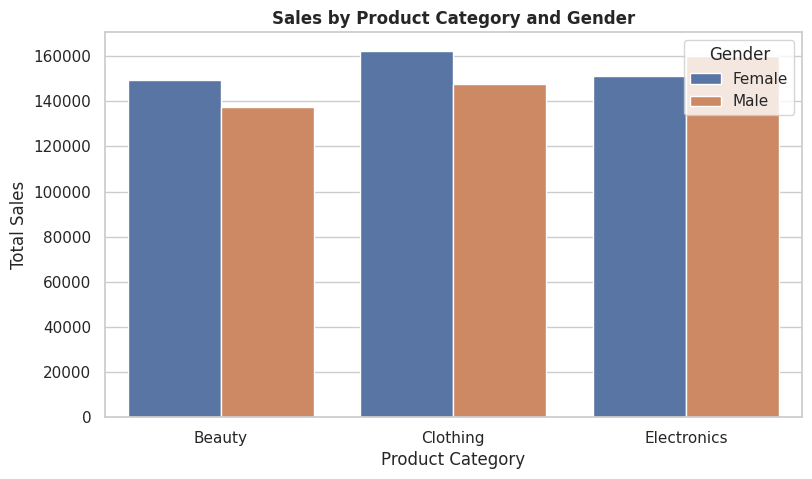

In [78]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=category_gender_sales,
    x='category',
    y='total_sales',
    hue='gender'
)

plt.title('Sales by Product Category and Gender')
plt.xlabel('Product Category')
plt.ylabel('Total Sales')
plt.legend(title='Gender')

plt.show()

**7. Key Insights and Recommendation**

In [79]:
key_insights = pd.DataFrame({
    'Metric': [
        'Total Sales',
        'Total Transactions',
        'Best Performing Category',
        'Highest Sales Age Group',
        'Highest Sales Gender',
        'Best Performing Quarter'
    ],

    'Result': [
        f"{df['total_sales'].sum():,.0f}",
        f"{df['transactions_id'].nunique():,}",
        category_analysis.iloc[0]['category'],
        age_group_sales.loc[
            age_group_sales['total_sales'].idxmax(),
            'age_group'
        ],
        gender_sales.loc[
            gender_sales['total_sales'].idxmax(),
            'gender'
        ],
        'Q4 2022'
    ]
})

key_insights

,Metric,Result
0,Total Sales,"908,230"
1,Total Transactions,"1,987"
2,Best Performing Category,Electronics
3,Highest Sales Age Group,46-55
4,Highest Sales Gender,Female
5,Best Performing Quarter,Q4 2022


<h2>Business Recommendations</h2>

<h3>1. Focus Marketing Efforts During Q4</h3>
<p>
Sales increase significantly from <b>September to December</b>, and Q4 is the strongest-performing quarter.
The business should increase inventory, promotions, and marketing campaigns before and during this period.
</p>

<h3>2. Target High-Value Customer Age Groups</h3>
<p>
Customers aged <b>46–55</b> generated the highest sales, followed closely by the <b>26–35</b> age group.
Personalized promotions and targeted marketing campaigns can help increase engagement and revenue from these valuable customer segments.
</p>

<h3>3. Strengthen the Electronics Category</h3>
<p>
<b>Electronics</b> generated the highest total revenue. The business should maintain product availability,
promote high-performing products, and use targeted campaigns to further increase sales.
</p>

<h3>4. Improve Beauty Category Performance</h3>
<p>
The <b>Beauty</b> category generated the lowest total sales among the three categories.
The business could experiment with promotions, product bundles, discounts, or targeted marketing campaigns to improve performance.
</p>

<h3>5. Use Gender-Based Marketing Strategically</h3>
<p>
Female customers generated slightly higher overall sales and performed particularly well in
<b>Beauty</b> and <b>Clothing</b>, while male customers showed stronger sales in
<b>Electronics</b>. Category-specific marketing campaigns could help improve customer targeting.
</p>

<h2>⚠️ Dataset Limitations</h2>

<ul>
    <li>The dataset contains product categories but does not include individual product names.</li>
    <li>Therefore, a Top 10 Best-Selling Products analysis could not be performed.</li>
    <li>Instead, the analysis focuses on product category performance based on total sales, quantity sold, and transaction count.</li>
</ul>

<h2>Conclusion</h2>

<p>
This exploratory data analysis examined retail sales data to identify important
sales trends, customer behavior, and product category performance.
</p>

<p>
The analysis found that <b>Electronics</b> generated the highest revenue, while
<b>Clothing</b> recorded the highest number of transactions and quantity sold.
Customers aged <b>46–55</b> generated the highest sales, and female customers
contributed slightly more revenue overall.
</p>

<p>
Sales showed a clear seasonal pattern, with <b>Q4 2022</b> being the strongest
quarter. The analysis also showed a strong positive relationship between
<b>price per unit</b> and total sales.
</p>

<p>
These insights can support better decisions related to inventory planning,
targeted marketing, customer segmentation, and product category strategy.
</p>

In [80]:
#END
